# Figure 1 — cell-fraction trajectories of all variants preceding AML

This notebook reproduces **Figure 1c**: the cell-fraction trajectories of every variant
detected at more than one timepoint in the longitudinal blood samples, in the **47 pre-AML
cases** (top) and the **46 age-matched controls** (bottom), coloured by the gene class of the
variant. Alongside each set of trajectories is a histogram of all cell-fraction measurements
(one count per variant per timepoint).

## What the panel shows

Each line is one variant (an SNV, indel or mosaic chromosomal alteration, mCA) tracked across
the serial samples of a single individual. The x-axis is time before AML diagnosis (for cases)
or before the diagnosis of the age-matched case (for controls); the y-axis is the fraction of
blood cells carrying the variant. Trajectories are coloured by the functional class of the
mutated gene (see key), and a white halo is drawn under each line so overlapping trajectories
remain legible. The vertical dotted line on the case panel marks AML diagnosis (t = 0).

## From VAF to cell fraction

Trajectories are plotted as **cell fraction** (the fraction of cells carrying the alteration),
not raw variant allele frequency (VAF):

- **SNVs / indels** are heterozygous, so cell fraction = 2 × VAF.
- **mCAs** (gains, losses, CN-LOH) are already reported as a cell fraction and are used directly.
- **Special case — a driver made homozygous by CN-LOH.** For `JAK2 V617F` on chr9p CN-LOH, and
  `TET2` on chr4q CN-LOH, the cells within the CN-LOH clone carry the mutation on both alleles
  (so there the VAF already equals a cell fraction), while cells outside it are heterozygous.
  The cell fraction is therefore reconstructed per timepoint as
  `CF = CF_CNLOH + 2 × (VAF − CF_CNLOH)`.

## Data availability

The input files listed below are **individual-level participant data** and are **not distributed with this code**. They are available under controlled access, deposited in the European Genome-phenome Archive (EGA) and released to approved researchers via a Data Access Committee administered by the corresponding authors.  With these files present in `Data_files/`, the notebook runs top to bottom and reproduces the published figure at full resolution.  The somatic variant calls underlying these trajectories are published in **Supplementary Tables 6 and 7** of the paper. 

| file  | used for | location |
|---|---|---|
| `UKCTOCS_samples_processed_information.csv` | time from each sample to AML diagnosis | EGA |
| `UKCTOCS_non-germline_variants_calls_SNVs_indels_mCAs.csv` | all somatic variant calls (VAFs / mCA cell fractions) | EGA |

## 1. Imports and plotting style

In [1]:
import csv
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# embed fonts as text (not outlines) so the vector PDF stays editable
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']

## 2. Colours

Each variant is coloured by the functional class of its gene. `mutation_classes` maps every
gene (and mCA type) on the panel to a class; `mutation_class_colors` gives each class its
colour. Greys are reused for axes and the histogram.

In [2]:
grey2, grey3, grey5 = '#cccccc', '#969696', '#252525'   # histogram fill, axes, diagnosis line
NPM1_RED = (1.00, 0.18, 0.33)
MCA_GREY = '#636363'

# gene / alteration  ->  functional class
mutation_classes = {
    'NPM1': 'NPM1',
    'DNMT3A': 'DNA methylation', 'TET2': 'DNA methylation',
    'IDH1': 'DNA methylation', 'IDH2': 'DNA methylation',
    'ASXL1': 'Chromatin modifiers', 'EZH2': 'Chromatin modifiers',
    'RUNX1': 'Transcription factors', 'CEBPA': 'Transcription factors',
    'GATA2': 'Transcription factors',
    'BCOR': 'Transcriptional corepressors', 'BCORL1': 'Transcriptional corepressors',
    'TP53': 'Tumour suppressor', 'PPM1D': 'Tumour suppressor', 'CHEK2': 'Tumour suppressor',
    'WT1': 'Tumour suppressor', 'CBL': 'Tumour suppressor', 'DDX41': 'Tumour suppressor',
    'SRSF2': 'Spliceosome', 'SF3B1': 'Spliceosome', 'U2AF1': 'Spliceosome',
    'ZRSR2': 'Spliceosome',
    'RAD21': 'Cohesin', 'STAG2': 'Cohesin',
    'FLT3': 'Cell signalling', 'KIT': 'Cell signalling', 'JAK2': 'Cell signalling',
    'KRAS': 'Cell signalling', 'NRAS': 'Cell signalling', 'PTPN11': 'Cell signalling',
    'CSF3R': 'Cell signalling', 'GNB1': 'Cell signalling', 'GNAS': 'Cell signalling',
    'MPL': 'Cell signalling',
    'mCA': 'mCA', '15q CNLOH': 'mCA', '4q CNLOH': 'mCA', 'X GAIN': 'mCA',
    '19p CNLOH': 'mCA', '19q CNLOH': 'mCA', '9p CNLOH': 'mCA', '7q LOSS': 'mCA'}

# functional class  ->  colour
mutation_class_colors = {
    'NPM1': NPM1_RED,
    'DNA methylation': '#5098BC',
    'Chromatin modifiers': '#E57E38',
    'Transcription factors': '#54AF51',
    'Transcriptional corepressors': '#1E8739',
    'Tumour suppressor': '#A460AD',
    'Spliceosome': '#C94776',
    'Cohesin': '#17AA9F',
    'Cell signalling': '#195BA6',
    'mCA': MCA_GREY}

## 3. Load data and build variant trajectories

### 3.1 Time from each sample to diagnosis

For controls, "time to diagnosis" is taken from the matched case, so cases and controls are
aligned on the same timeline.

In [3]:
df_samples = pd.read_csv('Data_files/UKCTOCS_samples_processed_information.csv')

# sample ID -> months from that sample to (matched) AML diagnosis
cases_timings_dict = (df_samples
                      .set_index('SAMPLE ID')['Time to Dx (from sample collection) (months)']
                      .to_dict())

### 3.2 Read the variant calls into per-individual trajectories

Each variant is keyed by `(variant, mutation_class, variant_type)`, and its trajectory is a
`{months_to_diagnosis: VAF}` dictionary. mCAs are recognised by their `variant_type`
(`CNLOH` / `CN-LOH` / `GAIN` / `LOSS`) and named by chromosome arm; their reported value is
already a cell fraction.

In [4]:
VARIANTS_CSV = 'Data_files/UKCTOCS_non-germline_variants_calls_SNVs_indels_mCAs.csv'

case_trajectories, control_trajectories = {}, {}

with open(VARIANTS_CSV) as csvfile:
    reader = csv.reader(csvfile)
    next(reader)                                      # skip header
    for row in reader:
        sample_name = row[0].split('_')[0] + '_' + row[0].split('_')[1]   # individual, e.g. C92_001
        sample_ID = row[0]                                                 # timepoint, e.g. C92_001_s1
        months_to_diagnosis = row[2]
        matched_sample = row[4]
        VAF = row[12] if row[12] != '' else 0
        variant_type = row[14]
        gene = row[15]
        AA_change = row[19]

        if VAF == 'not processed':
            continue

        # name the variant and assign its functional class
        if gene in mutation_classes:
            mutation_class = mutation_classes[gene]
            variant = gene + '_' + AA_change
        elif variant_type in ('CNLOH', 'CN-LOH', 'GAIN', 'LOSS'):
            mutation_class = 'mCA'
            variant = row[5] + '_' + variant_type                         # e.g. chr9p_CNLOH
        else:
            mutation_class = '-'

        is_case = sample_ID[:2] == 'C9'
        if not is_case:                                                   # align controls to their case
            months_to_diagnosis = cases_timings_dict[matched_sample]

        variant_ID = (variant, mutation_class, variant_type)
        store = case_trajectories if is_case else control_trajectories
        store.setdefault(sample_name, {}).setdefault(variant_ID, {})[float(months_to_diagnosis)] = float(VAF)

# sort each trajectory by time (latest -> earliest)
def sort_trajectories(trajectories):
    return {ind: {v: dict(sorted(traj.items(), reverse=True)) for v, traj in variants.items()}
            for ind, variants in trajectories.items()}

case_trajectories = sort_trajectories(case_trajectories)
control_trajectories = sort_trajectories(control_trajectories)

### 3.3 Convert VAF to cell fraction

Applies the rules described at the top of the notebook: mCAs are left as-is, `JAK2 V617F` and
`TET2` on their co-occurring CN-LOH are reconstructed per timepoint, and everything else is
doubled.

In [5]:
def combine_with_cnloh(traj, cnloh_traj):
    # a driver made homozygous within a CN-LOH clone: VAF == cell fraction inside the clone,
    # heterozygous (x2) outside it.  Where the CN-LOH was not measured, fall back to 2 x VAF.
    out = {}
    for age, vaf in traj.items():
        if age in cnloh_traj:
            cf = cnloh_traj[age]
            out[age] = cf + (vaf - cf) * 2
        else:
            out[age] = vaf * 2
    return out

def to_cell_fractions(trajectories):
    out = {}
    for ind, variants in trajectories.items():
        for variant_ID, traj in variants.items():
            name = variant_ID[0]
            if name[:3] == 'chr':                                    # mCA: already a cell fraction
                cf = dict(traj)
            elif name == 'JAK2_p.V617F' and ('chr9p_CNLOH', 'mCA', 'CNLOH') in variants:
                cf = combine_with_cnloh(traj, variants[('chr9p_CNLOH', 'mCA', 'CNLOH')])
            elif name[:4] == 'TET2' and ('chr4q_CNLOH', 'mCA', 'CNLOH') in variants:
                cf = combine_with_cnloh(traj, variants[('chr4q_CNLOH', 'mCA', 'CNLOH')])
            else:                                                    # heterozygous SNV / indel
                cf = {age: vaf * 2 for age, vaf in traj.items()}
            out.setdefault(ind, {})[variant_ID] = cf
    return out

case_cell_fractions = to_cell_fractions(case_trajectories)
control_cell_fractions = to_cell_fractions(control_trajectories)

# every cell-fraction measurement (one per variant per timepoint) for the histograms
def all_cell_fractions(trajectories):
    return [cf for variants in trajectories.values()
               for traj in variants.values() for cf in traj.values()]

## 4. Figure 1c

One helper draws both panels: the trajectories (only variants seen at more than one timepoint)
with the histogram of all cell-fraction measurements alongside.

In [ ]:
def plot_figure_1c(cases_or_controls, trajectories, xlabel, diagnosis_line=False):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17.25, 5), sharey=True,
                                   gridspec_kw={'width_ratios': [11, 1]})

    # --- left: cell-fraction trajectories ---
    n_variants = 0
    for ind, variants in trajectories.items():
        for (variant, mutation_class, variant_type), cf in variants.items():
            months = [-m for m in cf]                 # months before diagnosis (time runs right->left)
            fractions = list(cf.values())
            if len(months) > 1:                       # plot only variants seen at >1 timepoint
                n_variants += 1
                ax1.plot(months, fractions, color='white', lw=5)                       # halo
                ax1.plot(months, fractions, color=mutation_class_colors[mutation_class], lw=2)
    if diagnosis_line:
        ax1.plot([0, 0], [0, 1.0], lw=7, ls=':', color=grey5)                          # AML diagnosis

    ax1.set_xlim(-15 * 12, 0); ax1.set_ylim(0, 1.05)
    ax1.set_xticks([12 * y for y in range(-15, 1)]); ax1.set_xticklabels(range(-15, 1), fontsize=16)
    ax1.set_yticks([i / 10 for i in range(11)]); ax1.set_yticklabels(range(0, 101, 10), fontsize=16)
    ax1.set_xlabel(xlabel, fontsize=16)
    ax1.set_ylabel('fraction of cells (%)', fontsize=16)

    # --- right: histogram of cell-fraction measurements ---
    ax2.hist(all_cell_fractions(trajectories), bins=10, range=(0, 1),
             orientation='horizontal', color=grey2, edgecolor='black', lw=0.6)
    ax2.set_xlim(0, 400)
    ax2.set_xticks(range(0, 401, 50))
    ax2.set_xticklabels(['0', '', '', '', '200', '', '', '', '400'], fontsize=16)
    ax2.set_xlabel('no. of variants', fontsize=16)

    for ax in (ax1, ax2):
        ax.spines[['top', 'right']].set_visible(False)
        for side in ('bottom', 'left'):
            ax.spines[side].set_linewidth(1.5); ax.spines[side].set_color(grey3)
        ax.tick_params(width=1, color=grey3, length=6)

    plt.tight_layout()
    plt.show()
    print(f'{n_variants} variants plotted (detected at >1 timepoint)')

### 4a. Pre-AML cases

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


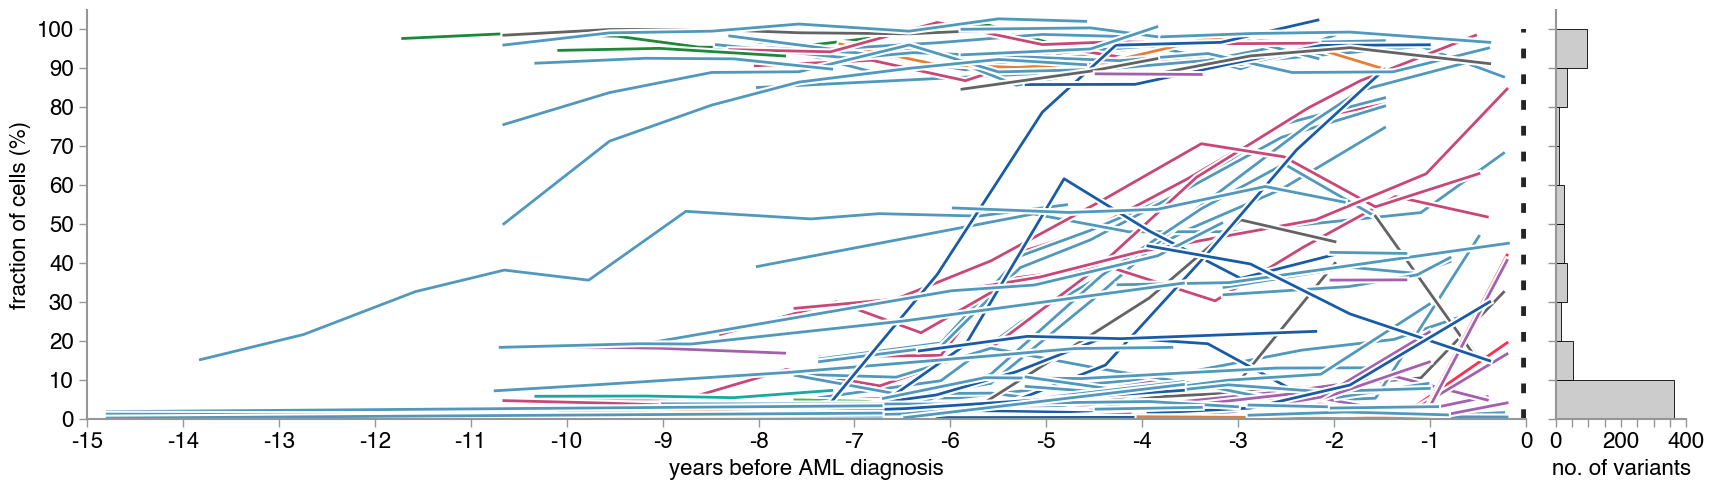

132 variants plotted (detected at >1 timepoint)


In [11]:
plot_figure_1c('cases', case_cell_fractions,
               xlabel='years before AML diagnosis',
               diagnosis_line=True)

### 4b. Age-matched controls

The study has 46 controls; one original control was excluded after later developing MDS and does
not appear in the variant calls.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


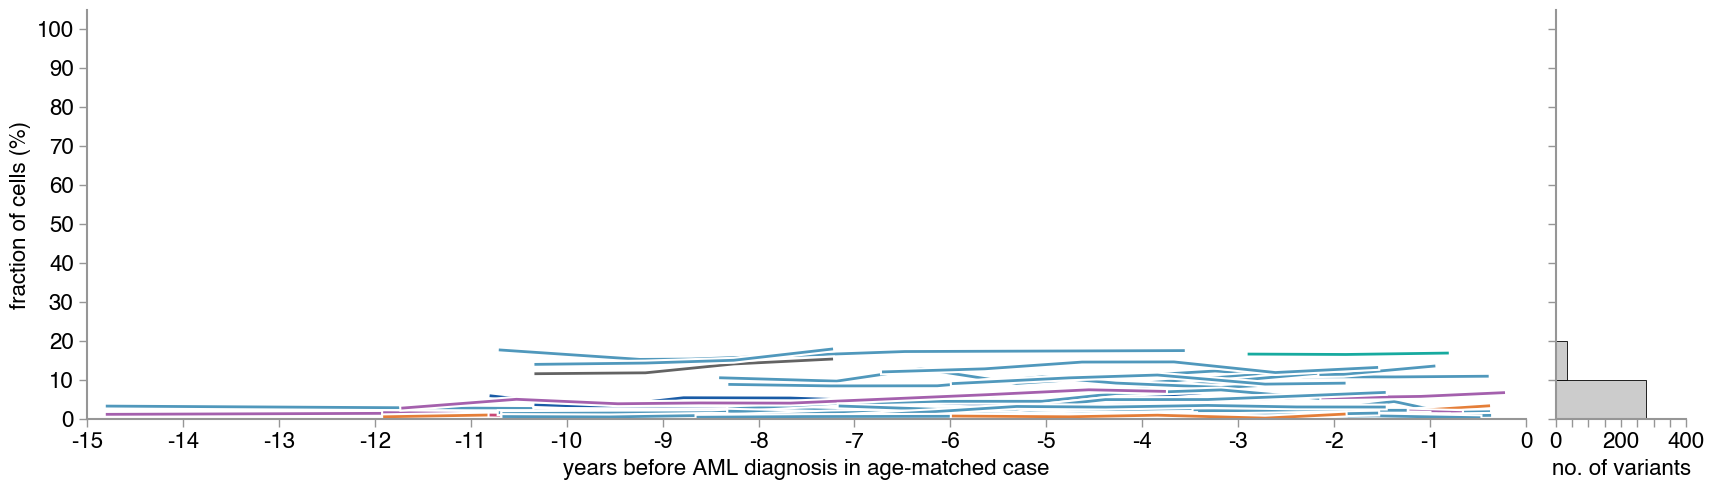

59 variants plotted (detected at >1 timepoint)


In [12]:
plot_figure_1c('controls', control_cell_fractions,
               xlabel='years before AML diagnosis in age-matched case')